# Round 2 EDA — R1 vs R2 Comparison
**Products:** `ASH_COATED_OSMIUM` · `INTARIAN_PEPPER_ROOT`  
**R1 days:** −2, −1, 0 &nbsp;|&nbsp; **R2 days:** −1, 0, 1  
**Focus:** Structural changes · Extra market access impact · Strategy validation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#0d1117',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#e6edf3',
    'xtick.color':'#8b949e','ytick.color':'#8b949e',
    'text.color':'#e6edf3','grid.color':'#21262d',
    'grid.linestyle':'--','axes.titlecolor':'#e6edf3',
    'axes.titlesize':10,'axes.labelsize':8,'font.size':8,'figure.dpi':110,
})

C_R1='#58a6ff'; C_R2='#3fb950'; C_BID='#3fb950'; C_ASK='#f85149'
C_FV='#58a6ff'; C_TRD='#d29922'; C_MID='#bc8cff'
DRIFT=0.001
R1DAYS=[-2,-1,0]; R2DAYS=[-1,0,1]
PRODS=['INTARIAN_PEPPER_ROOT','ASH_COATED_OSMIUM']
PLABELS={'INTARIAN_PEPPER_ROOT':'PEPPER_ROOT','ASH_COATED_OSMIUM':'OSMIUM'}
DS_R1={-2:10000,-1:11000,0:12000}; DS_R2={-1:11000,0:12000,1:13000}

def wall_mid(df):
    bp=df[['bid_price_1','bid_price_2','bid_price_3']].values
    bv=df[['bid_volume_1','bid_volume_2','bid_volume_3']].values
    ap=df[['ask_price_1','ask_price_2','ask_price_3']].values
    av=df[['ask_volume_1','ask_volume_2','ask_volume_3']].values
    bvf=np.where(np.isnan(bv),-1,bv); avf=np.where(np.isnan(av),-1,av)
    return (bp[np.arange(len(df)),np.argmax(bvf,1)]+ap[np.arange(len(df)),np.argmax(avf,1)])/2

def get_sub(prod,day,rnd):
    if rnd == 2:
        df=pd.read_csv(f'../data/ROUND_2/prices_round_{rnd}_day_{day}.csv',sep=';')
    else:
        df=pd.read_csv(f'../data/ROUND1/prices_round_{rnd}_day_{day}.csv',sep=';')
    df=df[df['product']==prod].copy().reset_index(drop=True)
    df['wm']=wall_mid(df)
    if prod=='INTARIAN_PEPPER_ROOT':
        ds=(DS_R1 if rnd==1 else DS_R2)[day]
        df['fv']=ds+df['timestamp'].astype(float)*DRIFT
        df['det']=df['wm']-df['fv']
    else:
        df['fv']=10000.0; df['det']=df['wm']-10000
    df['spread']=df['ask_price_1']-df['bid_price_1']
    return df

def get_trades(prod,day,rnd):
    if rnd == 2:
        t=pd.read_csv(f'../data/ROUND_2/trades_round_{rnd}_day_{day}.csv',sep=';')
    else:
        t=pd.read_csv(f'../data/ROUND1/trades_round_{rnd}_day_{day}.csv',sep=';')
    return t[t['symbol']==prod].copy()

print('Loaded.')
for rnd,days in [(1,R1DAYS),(2,R2DAYS)]:
    for prod in PRODS:
        total=sum(len(get_trades(prod,d,rnd)) for d in days)
        print(f'  R{rnd} {PLABELS[prod]}: {total} trades ({total//3}/day)')

Loaded.
  R1 PEPPER_ROOT: 1011 trades (337/day)
  R1 OSMIUM: 1265 trades (421/day)
  R2 PEPPER_ROOT: 996 trades (332/day)
  R2 OSMIUM: 1395 trades (465/day)


---
## Section 1 — Price Overview: All 6 Days
Wall mid, fair value, and trades. Orange border separates R1 from R2.

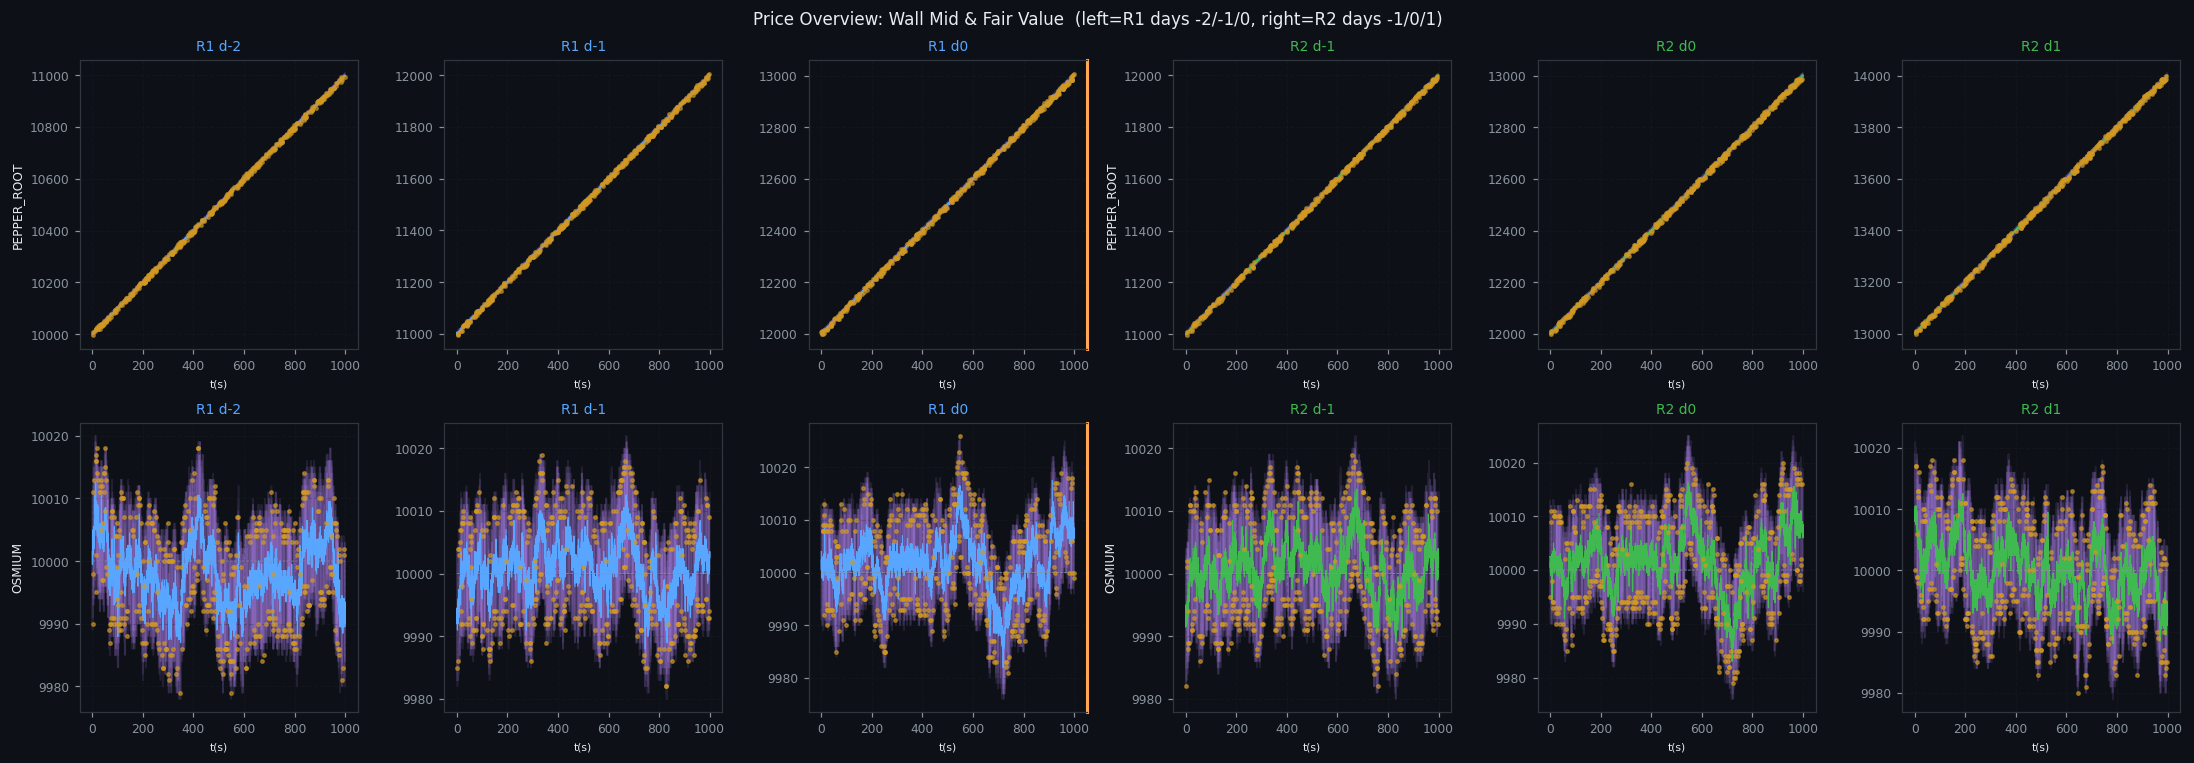

In [5]:
fig,axes=plt.subplots(2,6,figsize=(20,7))
fig.suptitle('Price Overview: Wall Mid & Fair Value  (left=R1 days -2/-1/0, right=R2 days -1/0/1)',fontsize=11)
fig.patch.set_facecolor('#0d1117')
col=0
for rnd,days in [(1,R1DAYS),(2,R2DAYS)]:
    for day in days:
        for row,prod in enumerate(PRODS):
            ax=axes[row][col]; df=get_sub(prod,day,rnd); t=get_trades(prod,day,rnd)
            ts=df['timestamp']/1000; c=C_R1 if rnd==1 else C_R2
            ax.fill_between(ts,df['bid_price_1'],df['ask_price_1'],alpha=0.12,color=C_MID)
            ax.plot(ts,df['wm'],color=c,lw=0.8)
            ax.plot(ts,df['fv'],color='#8b949e',lw=0.5,ls='--')
            if len(t): ax.scatter(t['timestamp']/1000,t['price'],c=C_TRD,s=5,zorder=5,alpha=0.6)
            ax.set_title(f'R{rnd} d{day}',color=c,fontsize=9)
            if col in(0,3): ax.set_ylabel(PLABELS[prod],fontsize=8)
            ax.set_xlabel('t(s)',fontsize=7); ax.grid(True,alpha=0.25)
        col+=1
# Orange divider between R1 and R2
for row in range(2):
    axes[row][2].spines['right'].set_color('#ffa657'); axes[row][2].spines['right'].set_linewidth(2)
plt.tight_layout(); plt.show()

---
## Section 2 — Detrended Residual & ACF
Removes the +1000/day trend from PEPPER_ROOT. Mean-reversion structure and stability.

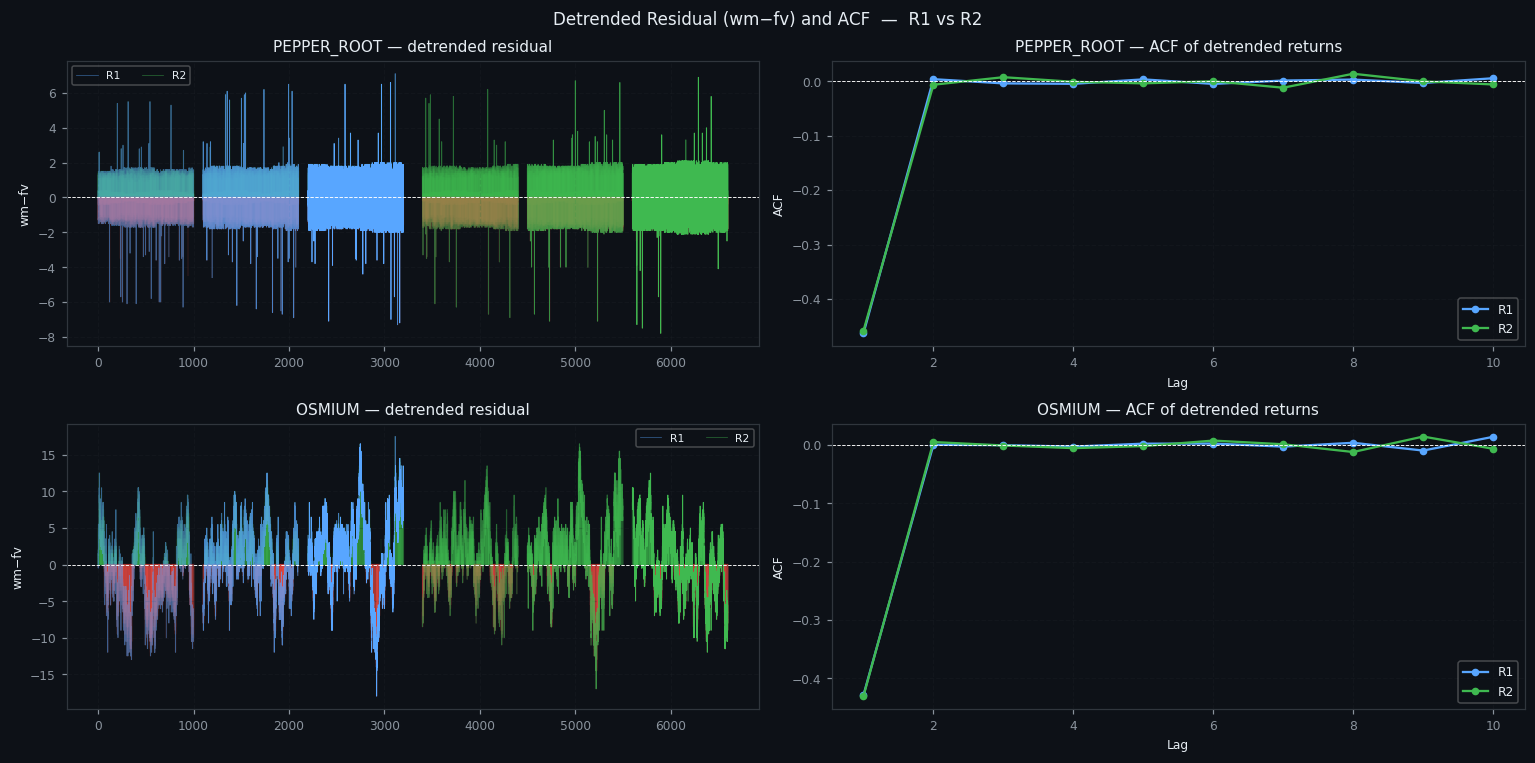

Lag-1 ACF:
  PEPPER_ROOT R1: ['-0.474', '-0.463', '-0.452'] mean=-0.463
  PEPPER_ROOT R2: ['-0.456', '-0.461', '-0.459'] mean=-0.459
  OSMIUM R1: ['-0.434', '-0.434', '-0.419'] mean=-0.429
  OSMIUM R2: ['-0.421', '-0.434', '-0.437'] mean=-0.431


In [6]:
fig,axes=plt.subplots(2,2,figsize=(14,7))
fig.suptitle('Detrended Residual (wm−fv) and ACF  —  R1 vs R2',fontsize=11)
fig.patch.set_facecolor('#0d1117')
for row,prod in enumerate(PRODS):
    ax=axes[row][0]
    for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
        for i,day in enumerate(days):
            df=get_sub(prod,day,rnd); ts=df['timestamp']/1000+i*1100+(rnd-1)*3400; det=df['det']
            ax.plot(ts,det,color=color,lw=0.5,alpha=0.5+0.25*i,label=f'R{rnd}' if i==0 else None)
            ax.fill_between(ts,det,0,where=det>0,alpha=0.1,color=C_BID)
            ax.fill_between(ts,det,0,where=det<0,alpha=0.1,color=C_ASK)
    ax.axhline(0,color='white',lw=0.6,ls='--')
    ax.set_title(f'{PLABELS[prod]} — detrended residual'); ax.set_ylabel('wm−fv')
    ax.legend(fontsize=7,framealpha=0.3,ncol=2); ax.grid(True,alpha=0.25)
    ax2=axes[row][1]
    for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
        acf_avg=[np.mean([get_sub(prod,d,rnd)['det'].diff().dropna().autocorr(lag)
                          for d in days]) for lag in range(1,11)]
        ax2.plot(range(1,11),acf_avg,color=color,lw=1.5,marker='o',ms=4,label=f'R{rnd}')
    ax2.axhline(0,color='white',lw=0.6,ls='--')
    ax2.set_title(f'{PLABELS[prod]} — ACF of detrended returns')
    ax2.set_xlabel('Lag'); ax2.set_ylabel('ACF')
    ax2.legend(fontsize=8,framealpha=0.3); ax2.grid(True,alpha=0.25)
plt.tight_layout(); plt.show()
print('Lag-1 ACF:')
for prod in PRODS:
    for rnd,days in [(1,R1DAYS),(2,R2DAYS)]:
        acfs=[get_sub(prod,d,rnd)['det'].diff().dropna().autocorr(1) for d in days]
        print(f'  {PLABELS[prod]} R{rnd}: {[f"{a:.3f}" for a in acfs]} mean={np.mean(acfs):.3f}')

---
## Section 3 — Spread & Ask Offset from Fair Value
Bot quote placement and volume structure — has extra access changed anything?

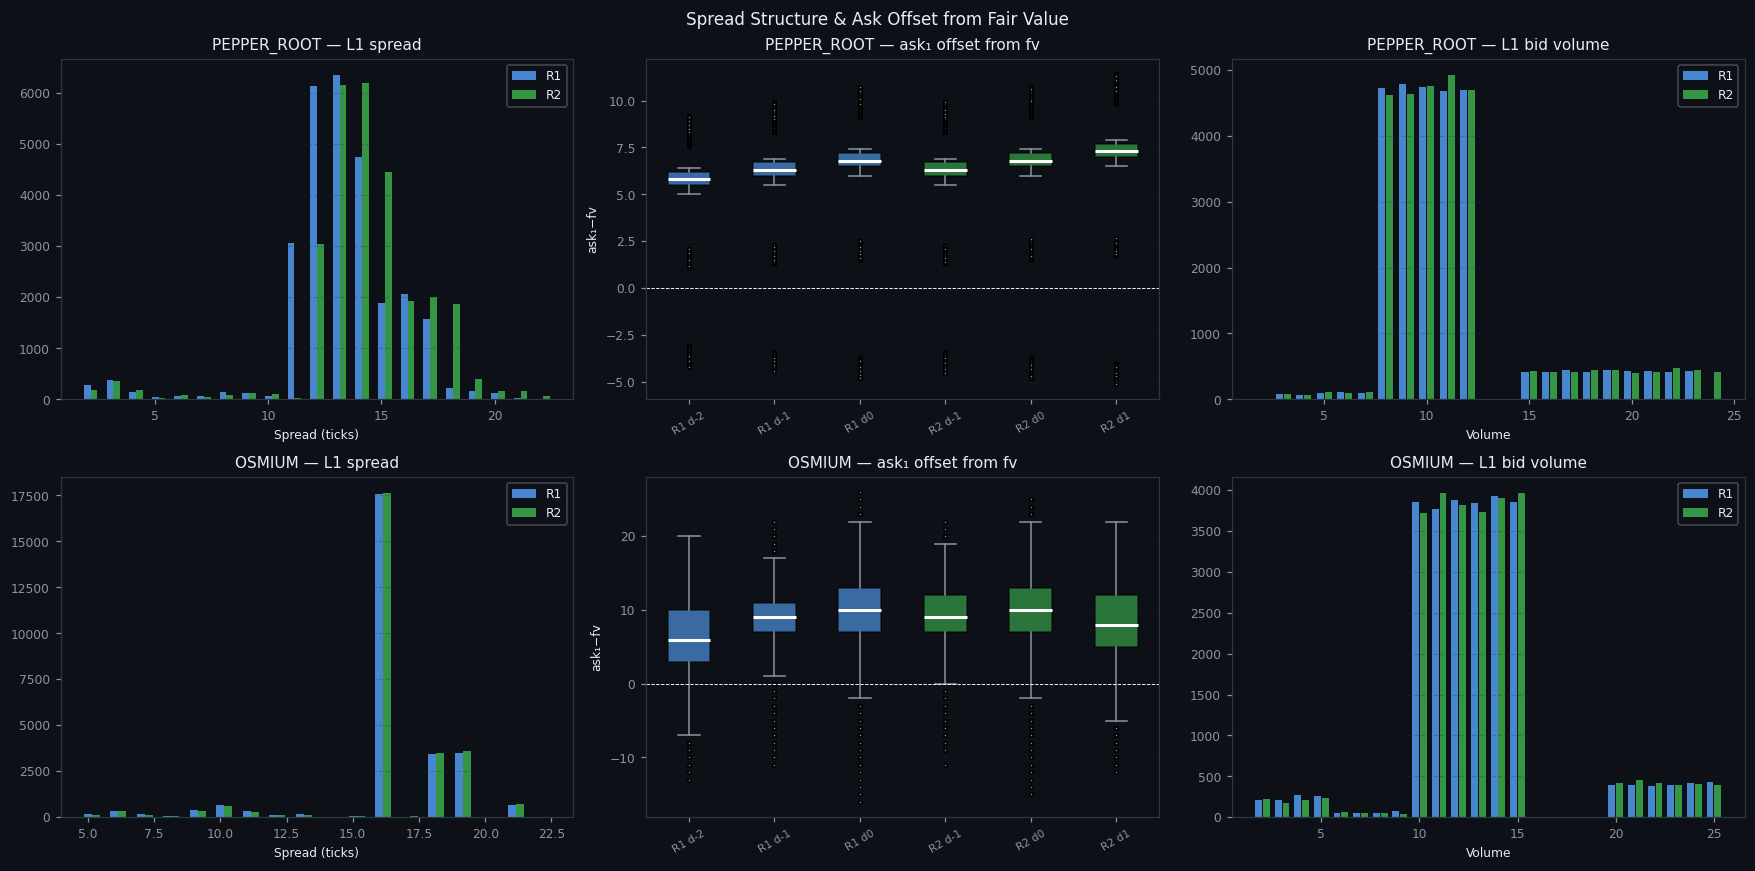

In [7]:
fig,axes=plt.subplots(2,3,figsize=(16,8))
fig.suptitle('Spread Structure & Ask Offset from Fair Value',fontsize=11)
fig.patch.set_facecolor('#0d1117')
for row,prod in enumerate(PRODS):
    # L1 spread histogram
    ax0=axes[row][0]
    for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
        sprs=[v for d in days for v in get_sub(prod,d,rnd)['spread'].dropna().round(0).tolist()]
        vc=pd.Series(sprs).value_counts().sort_index()
        ax0.bar(np.array(vc.index)+(0.3 if rnd==2 else 0),vc.values,0.3,color=color,alpha=0.8,label=f'R{rnd}')
    ax0.set_title(f'{PLABELS[prod]} — L1 spread'); ax0.set_xlabel('Spread (ticks)')
    ax0.legend(fontsize=8,framealpha=0.3); ax0.grid(True,axis='y',alpha=0.25)
    # Ask offset boxplot
    ax1=axes[row][1]
    data=[((get_sub(prod,d,rnd)['ask_price_1']-get_sub(prod,d,rnd)['fv']).dropna().values,f'R{rnd} d{d}',C_R1 if rnd==1 else C_R2)
          for rnd,days in [(1,R1DAYS),(2,R2DAYS)] for d in days]
    bp=ax1.boxplot([d[0] for d in data],labels=[d[1] for d in data],patch_artist=True,
                   medianprops=dict(color='white',lw=2),whiskerprops=dict(color='#8b949e'),
                   capprops=dict(color='#8b949e'),flierprops=dict(markerfacecolor='#8b949e',ms=2))
    for patch,d in zip(bp['boxes'],data): patch.set_facecolor(d[2]); patch.set_alpha(0.6)
    ax1.axhline(0,color='white',lw=0.6,ls='--')
    ax1.set_title(f'{PLABELS[prod]} — ask₁ offset from fv'); ax1.set_ylabel('ask₁−fv')
    ax1.tick_params(axis='x',labelsize=7,rotation=30); ax1.grid(True,axis='y',alpha=0.25)
    # L1 bid volume
    ax2=axes[row][2]
    for rnd,days,color,off in [(1,R1DAYS,C_R1,-0.2),(2,R2DAYS,C_R2,0.2)]:
        vols=[v for d in days for v in get_sub(prod,d,rnd)['bid_volume_1'].dropna().astype(int).tolist()]
        vc=pd.Series(vols).value_counts().sort_index().head(20)
        ax2.bar(np.array(vc.index)+off,vc.values,0.35,color=color,alpha=0.8,label=f'R{rnd}')
    ax2.set_title(f'{PLABELS[prod]} — L1 bid volume'); ax2.set_xlabel('Volume')
    ax2.legend(fontsize=8,framealpha=0.3); ax2.grid(True,axis='y',alpha=0.25)
plt.tight_layout(); plt.show()

---
## Section 4 — Trade Count & Timing: Extra Market Access Impact
R2 provides 25% more quotes to top-50% MAF bidders. Trade counts tell us if it shows.

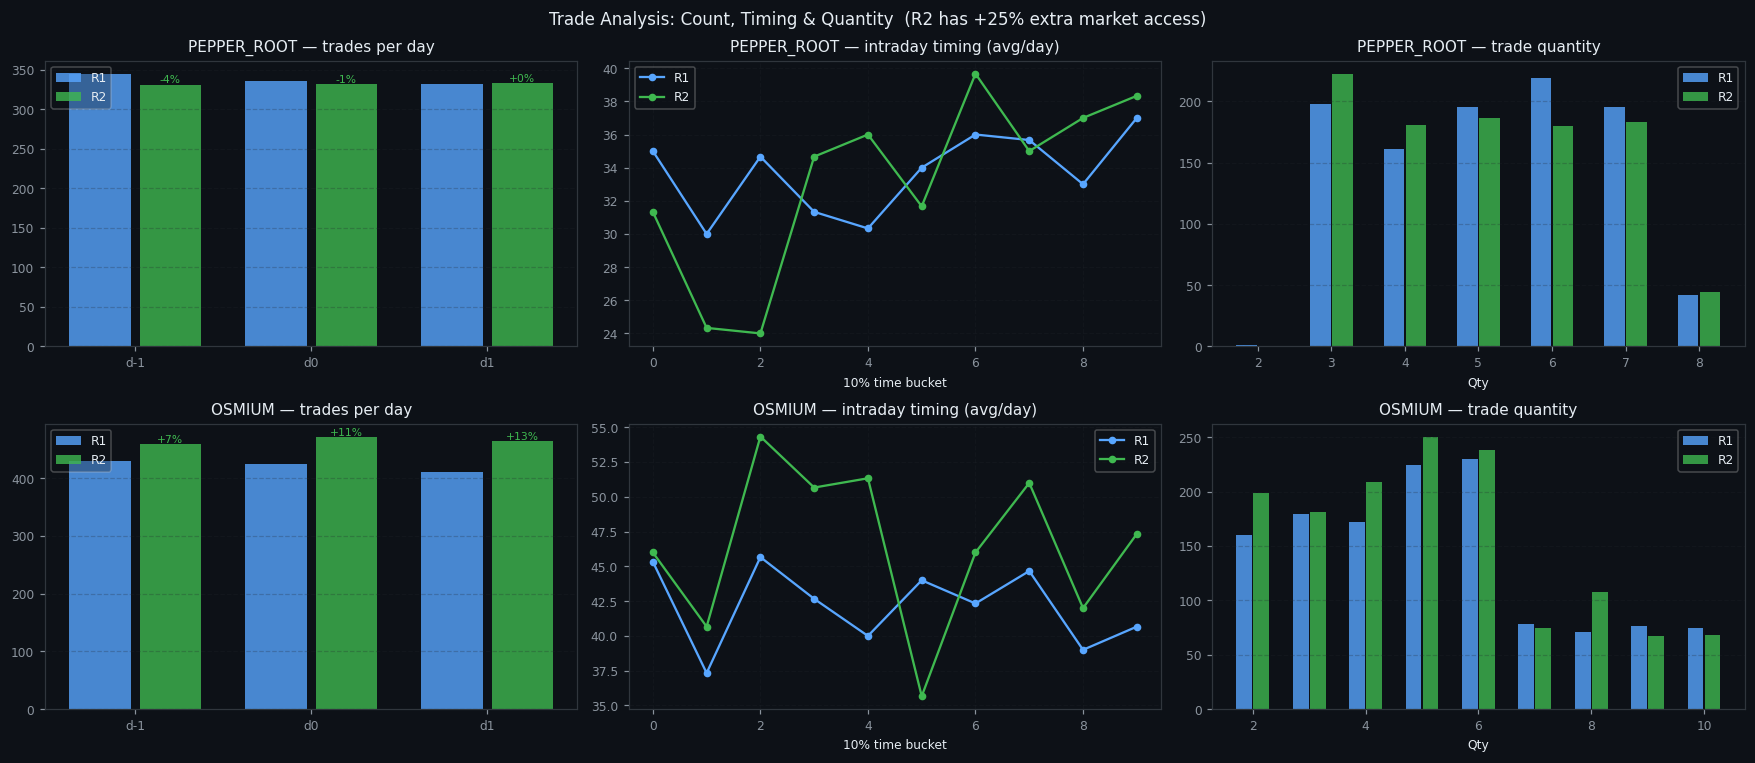

Trade totals:
  PEPPER_ROOT: R1=1011 (337/day) R2=996 (332/day) [-1.5%]
  OSMIUM: R1=1265 (421/day) R2=1395 (465/day) [+10.3%]


In [8]:
fig,axes=plt.subplots(2,3,figsize=(16,7))
fig.suptitle('Trade Analysis: Count, Timing & Quantity  (R2 has +25% extra market access)',fontsize=11)
fig.patch.set_facecolor('#0d1117')
for row,prod in enumerate(PRODS):
    ax0=axes[row][0]
    r1c=[len(get_trades(prod,d,1)) for d in R1DAYS]
    r2c=[len(get_trades(prod,d,2)) for d in R2DAYS]
    x=np.arange(3)
    ax0.bar(x-0.2,r1c,0.35,color=C_R1,alpha=0.8,label='R1')
    ax0.bar(x+0.2,r2c,0.35,color=C_R2,alpha=0.8,label='R2')
    for xi,(r1,r2) in enumerate(zip(r1c,r2c)):
        pct=100*(r2-r1)/r1
        ax0.text(xi+0.2,r2+2,f'{pct:+.0f}%',ha='center',fontsize=7,color=C_R2)
    ax0.set_xticks(x); ax0.set_xticklabels([f'd{d}' for d in [-1,0,1]])
    ax0.set_title(f'{PLABELS[prod]} — trades per day'); ax0.legend(fontsize=8,framealpha=0.3)
    ax0.grid(True,axis='y',alpha=0.25)
    ax1=axes[row][1]
    for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
        buckets=np.zeros(10)
        for day in days:
            t=get_trades(prod,day,rnd); b=(t['timestamp']//100000).astype(int).clip(0,9)
            for bi in range(10): buckets[bi]+=(b==bi).sum()
        ax1.plot(range(10),buckets/len(days),color=color,lw=1.5,marker='o',ms=4,label=f'R{rnd}')
    ax1.set_title(f'{PLABELS[prod]} — intraday timing (avg/day)')
    ax1.set_xlabel('10% time bucket'); ax1.legend(fontsize=8,framealpha=0.3); ax1.grid(True,alpha=0.25)
    ax2=axes[row][2]
    for rnd,days,color,off in [(1,R1DAYS,C_R1,-0.15),(2,R2DAYS,C_R2,0.15)]:
        qtys=[q for d in days for q in get_trades(prod,d,rnd)['quantity'].tolist()]
        vc=pd.Series(qtys).value_counts().sort_index()
        ax2.bar(np.array(vc.index)+off,vc.values,0.28,color=color,alpha=0.8,label=f'R{rnd}')
    ax2.set_title(f'{PLABELS[prod]} — trade quantity'); ax2.set_xlabel('Qty')
    ax2.legend(fontsize=8,framealpha=0.3); ax2.grid(True,axis='y',alpha=0.25)
plt.tight_layout(); plt.show()
print('Trade totals:')
for prod in PRODS:
    r1=sum(len(get_trades(prod,d,1)) for d in R1DAYS)
    r2=sum(len(get_trades(prod,d,2)) for d in R2DAYS)
    print(f'  {PLABELS[prod]}: R1={r1} ({r1//3}/day) R2={r2} ({r2//3}/day) [{100*(r2-r1)/r1:+.1f}%]')

---
## Section 5 — OSMIUM: L2 Asymmetry Signal (R1 vs R2)
The hidden pattern: when only one side has L2 depth, price moves toward it.

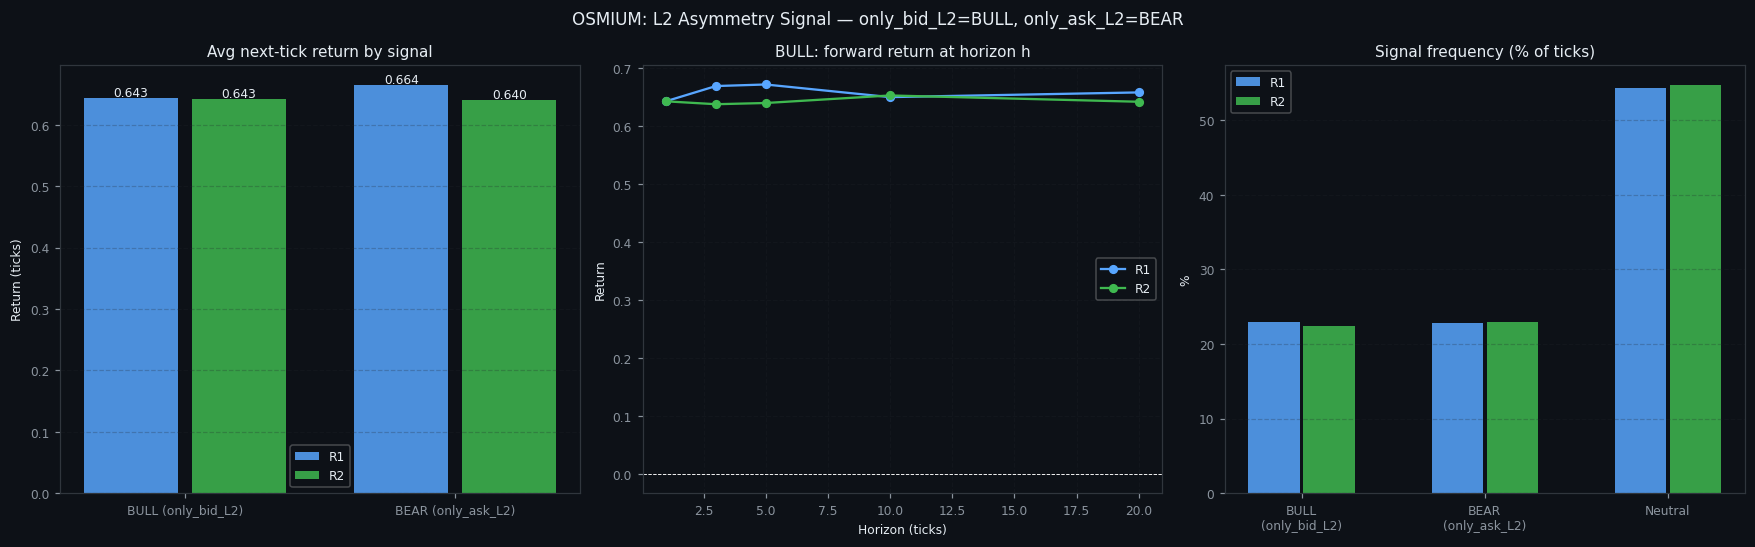

L2 signal:
  R1: BULL=+0.6429, BEAR=+0.6642
  R2: BULL=+0.6426, BEAR=+0.6398


In [9]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle('OSMIUM: L2 Asymmetry Signal — only_bid_L2=BULL, only_ask_L2=BEAR',fontsize=11)
fig.patch.set_facecolor('#0d1117')
summary={'R1':{'bull':[],'bear':[]},'R2':{'bull':[],'bear':[]}}
for rnd,days in [(1,R1DAYS),(2,R2DAYS)]:
    for day in days:
        df=get_sub('ASH_COATED_OSMIUM',day,rnd).dropna(subset=['wm']).reset_index(drop=True)
        wm=df['wm'].values; ret=np.diff(wm)
        l2b=df['bid_volume_2'].notna().values; l2a=df['ask_volume_2'].notna().values
        ob=(l2b&~l2a)[:-1]; oa=(~l2b&l2a)[:-1]
        summary[f'R{rnd}']['bull'].append(ret[ob].mean())
        summary[f'R{rnd}']['bear'].append(-ret[oa].mean())
ax0=axes[0]
for rnd_k,color in [('R1',C_R1),('R2',C_R2)]:
    ba=np.mean(summary[rnd_k]['bull']); br=np.mean(summary[rnd_k]['bear'])
    off=-0.2 if rnd_k=='R1' else 0.2
    ax0.bar([0+off,1+off],[ba,br],0.35,color=color,alpha=0.85,label=rnd_k)
    ax0.text(0+off,ba+0.003,f'{ba:.3f}',ha='center',fontsize=8)
    ax0.text(1+off,br+0.003,f'{br:.3f}',ha='center',fontsize=8)
ax0.set_xticks([0,1]); ax0.set_xticklabels(['BULL (only_bid_L2)','BEAR (only_ask_L2)'])
ax0.set_title('Avg next-tick return by signal'); ax0.set_ylabel('Return (ticks)')
ax0.legend(fontsize=8,framealpha=0.3); ax0.grid(True,axis='y',alpha=0.25)
ax1=axes[1]; horizons=[1,3,5,10,20]
for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
    bull_h={h:[] for h in horizons}
    for day in days:
        df=get_sub('ASH_COATED_OSMIUM',day,rnd).dropna(subset=['wm']).reset_index(drop=True)
        wm=df['wm'].values; l2b=df['bid_volume_2'].notna().values; l2a=df['ask_volume_2'].notna().values
        ob=l2b&~l2a
        for h in horizons:
            [bull_h[h].append(wm[i+h]-wm[i]) for i in range(len(wm)-h) if ob[i]]
    ax1.plot(horizons,[np.mean(bull_h[h]) for h in horizons],color=color,lw=1.5,marker='o',ms=5,label=f'R{rnd}')
ax1.axhline(0,color='white',lw=0.6,ls='--'); ax1.set_title('BULL: forward return at horizon h')
ax1.set_xlabel('Horizon (ticks)'); ax1.set_ylabel('Return'); ax1.legend(fontsize=8,framealpha=0.3); ax1.grid(True,alpha=0.25)
ax2=axes[2]
for rnd,days,color,off in [(1,R1DAYS,C_R1,-0.15),(2,R2DAYS,C_R2,0.15)]:
    freqs=[]
    for day in days:
        df=get_sub('ASH_COATED_OSMIUM',day,rnd)
        l2b=df['bid_volume_2'].notna().values; l2a=df['ask_volume_2'].notna().values; n=len(df)
        freqs.append([100*(l2b&~l2a).sum()/n,100*(~l2b&l2a).sum()/n,100*(~(l2b&~l2a)&~(~l2b&l2a)).sum()/n])
    means=np.mean(freqs,axis=0)
    ax2.bar(np.arange(3)+off,means,0.28,color=color,alpha=0.85,label=f'R{rnd}')
ax2.set_xticks([0,1,2]); ax2.set_xticklabels(['BULL\n(only_bid_L2)','BEAR\n(only_ask_L2)','Neutral'])
ax2.set_title('Signal frequency (% of ticks)'); ax2.set_ylabel('%')
ax2.legend(fontsize=8,framealpha=0.3); ax2.grid(True,axis='y',alpha=0.25)
plt.tight_layout(); plt.show()
print('L2 signal:')
for rnd_k in ['R1','R2']:
    print(f'  {rnd_k}: BULL={np.mean(summary[rnd_k]["bull"]):+.4f}, BEAR={np.mean(summary[rnd_k]["bear"]):+.4f}')

---
## Section 6 — PEPPER_ROOT: Drift Stability & EMA Risk Check
Is the +0.001/tick drift intact? Does the EMA risk trigger ever fire?

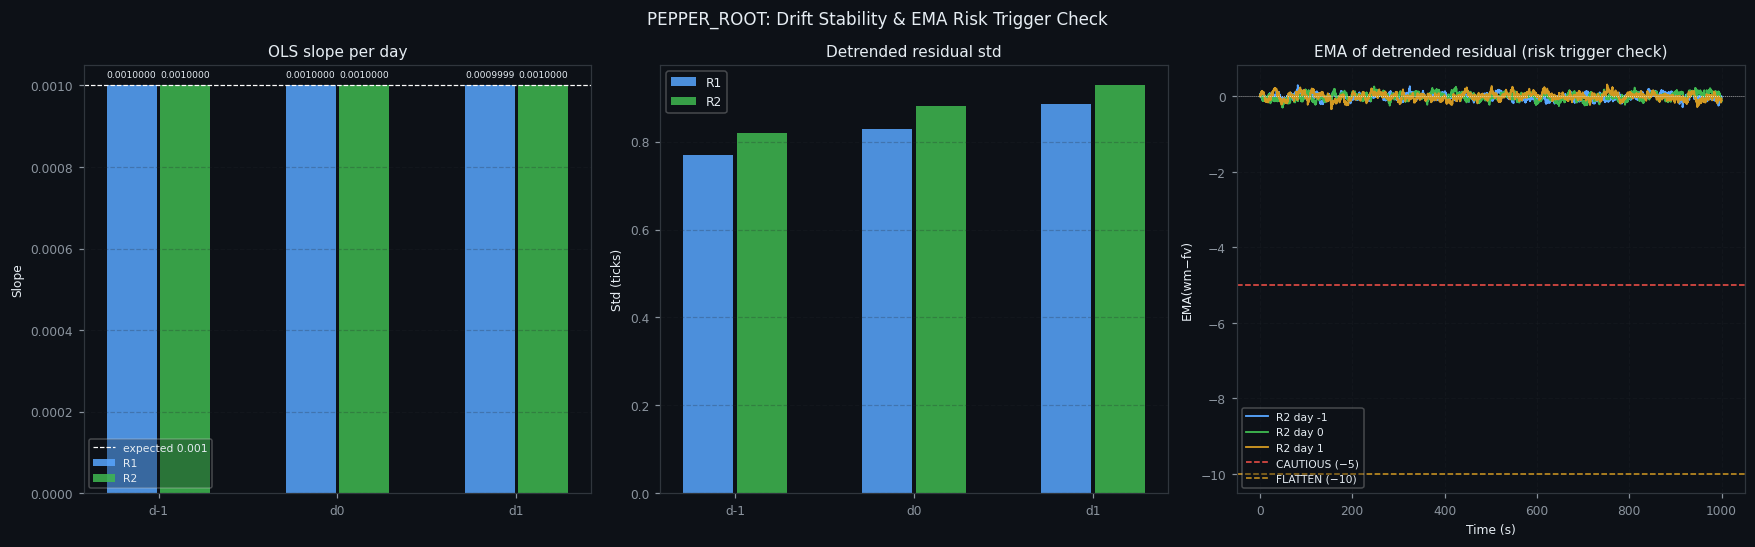

Drift summary:
  R1 d-2: slope=0.0010000, det_std=0.770
  R1 d-1: slope=0.0010000, det_std=0.829
  R1 d0: slope=0.0009999, det_std=0.886
  R2 d-1: slope=0.0010000, det_std=0.819
  R2 d0: slope=0.0010000, det_std=0.881
  R2 d1: slope=0.0010000, det_std=0.928


In [10]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle('PEPPER_ROOT: Drift Stability & EMA Risk Trigger Check',fontsize=11)
fig.patch.set_facecolor('#0d1117')
ax0=axes[0]
for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
    slopes=[np.polyfit(get_sub('INTARIAN_PEPPER_ROOT',d,rnd).dropna(subset=['wm'])['timestamp'].astype(float),
                       get_sub('INTARIAN_PEPPER_ROOT',d,rnd).dropna(subset=['wm'])['wm'],1)[0] for d in days]
    off=-0.15 if rnd==1 else 0.15
    ax0.bar(np.arange(3)+off,slopes,0.28,color=color,alpha=0.85,label=f'R{rnd}')
    for i,s in enumerate(slopes): ax0.text(i+off,s+0.00002,f'{s:.7f}',ha='center',fontsize=6)
ax0.axhline(0.001,color='white',lw=0.8,ls='--',label='expected 0.001')
ax0.set_xticks(range(3)); ax0.set_xticklabels([f'd{d}' for d in [-1,0,1]])
ax0.set_title('OLS slope per day'); ax0.set_ylabel('Slope'); ax0.legend(fontsize=7,framealpha=0.3); ax0.grid(True,axis='y',alpha=0.25)
ax1=axes[1]
for rnd,days,color in [(1,R1DAYS,C_R1),(2,R2DAYS,C_R2)]:
    stds=[get_sub('INTARIAN_PEPPER_ROOT',d,rnd)['det'].std() for d in days]
    off=-0.15 if rnd==1 else 0.15
    ax1.bar(np.arange(3)+off,stds,0.28,color=color,alpha=0.85,label=f'R{rnd}')
ax1.set_xticks(range(3)); ax1.set_xticklabels([f'd{d}' for d in [-1,0,1]])
ax1.set_title('Detrended residual std'); ax1.set_ylabel('Std (ticks)')
ax1.legend(fontsize=8,framealpha=0.3); ax1.grid(True,axis='y',alpha=0.25)
ax2=axes[2]
alpha_ema=0.02
for day,color in [(-1,'#58a6ff'),(0,'#3fb950'),(1,'#d29922')]:
    df=get_sub('INTARIAN_PEPPER_ROOT',day,2).dropna(subset=['det'])
    det=df['det'].values; ema=np.zeros(len(det))
    for i in range(1,len(det)): ema[i]=alpha_ema*det[i]+(1-alpha_ema)*ema[i-1]
    ax2.plot(df['timestamp']/1000,ema,color=color,lw=1.2,label=f'R2 day {day}')
ax2.axhline(-5,color=C_ASK,lw=1,ls='--',label='CAUTIOUS (−5)')
ax2.axhline(-10,color='#d29922',lw=1,ls='--',label='FLATTEN (−10)')
ax2.axhline(0,color='white',lw=0.5,ls=':')
ax2.set_title('EMA of detrended residual (risk trigger check)')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('EMA(wm−fv)')
ax2.legend(fontsize=7,framealpha=0.3); ax2.grid(True,alpha=0.25)
plt.tight_layout(); plt.show()
print('Drift summary:')
for rnd,days in [(1,R1DAYS),(2,R2DAYS)]:
    for day in days:
        df=get_sub('INTARIAN_PEPPER_ROOT',day,rnd).dropna(subset=['wm'])
        s=np.polyfit(df['timestamp'].astype(float),df['wm'],1)[0]
        print(f'  R{rnd} d{day}: slope={s:.7f}, det_std={df["det"].std():.3f}')

---
## Section 7 — Volume Fingerprint & Trade Offset Distributions
Bot volume regimes and where trades occur relative to fair value.

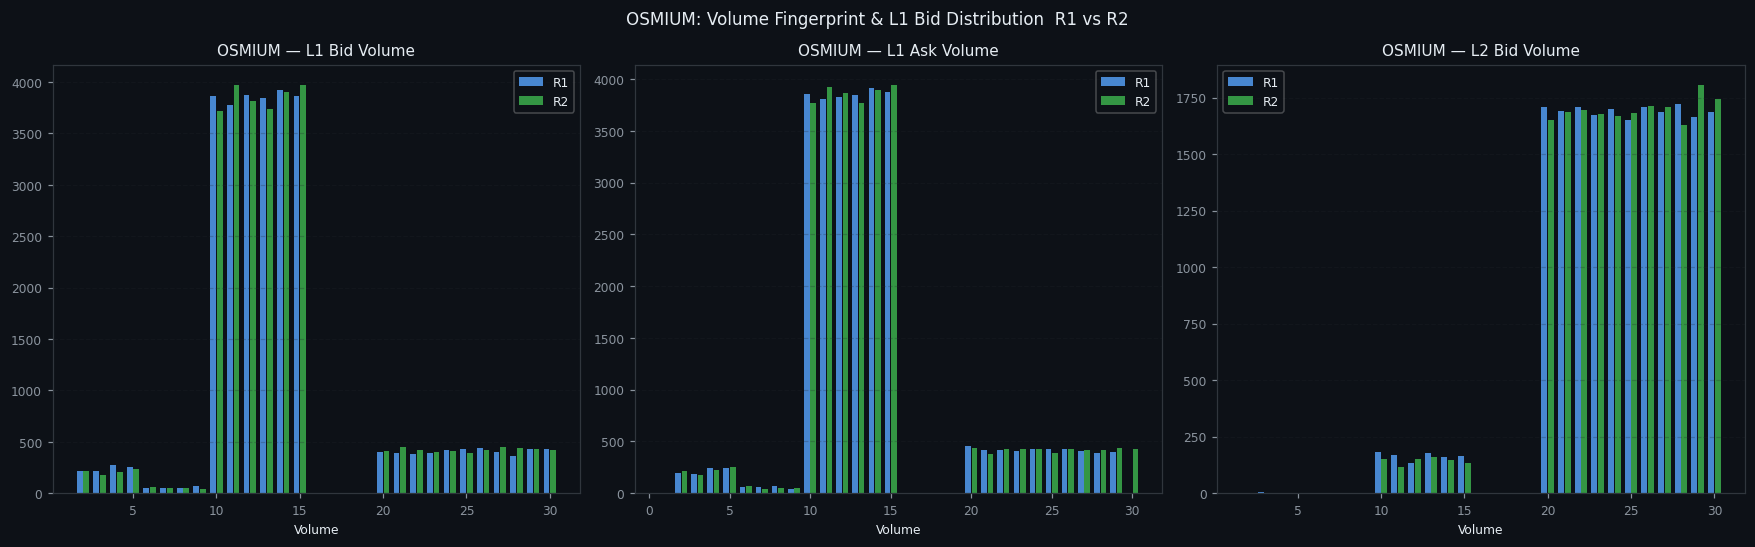

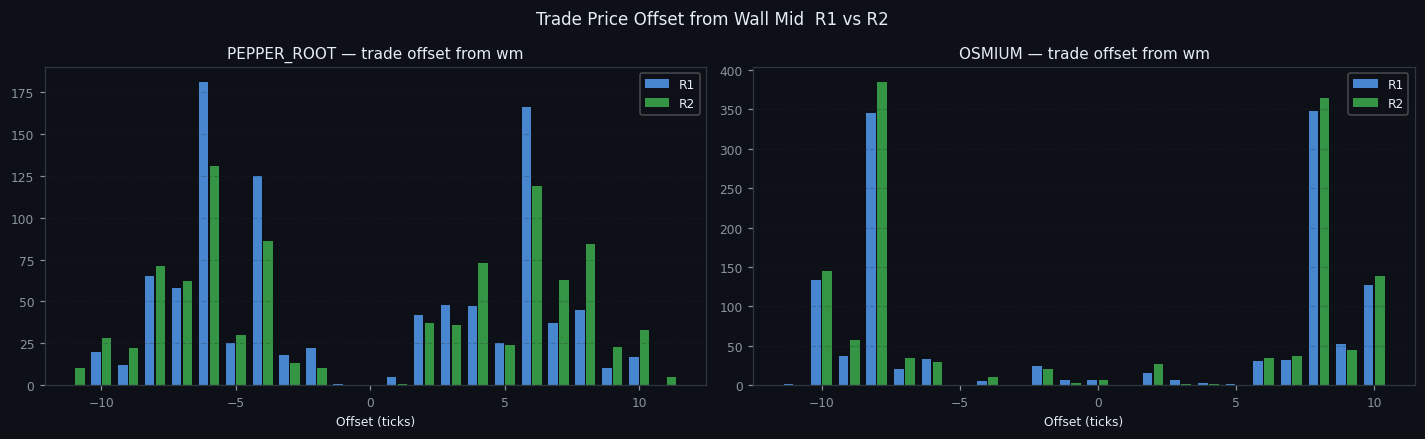

In [11]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
fig.suptitle('OSMIUM: Volume Fingerprint & L1 Bid Distribution  R1 vs R2',fontsize=11)
fig.patch.set_facecolor('#0d1117')
for ax,col_key,title in [
    (axes[0],'bid_volume_1','L1 Bid Volume'),
    (axes[1],'ask_volume_1','L1 Ask Volume'),
    (axes[2],'bid_volume_2','L2 Bid Volume'),
]:
    for rnd,days,color,off in [(1,R1DAYS,C_R1,-0.2),(2,R2DAYS,C_R2,0.2)]:
        vals=[v for d in days for v in get_sub('ASH_COATED_OSMIUM',d,rnd)[col_key].dropna().astype(int).tolist()]
        vc=pd.Series(vals).value_counts().sort_index()
        top=vc.head(25); ax.bar(np.array(top.index)+off,top.values,0.35,color=color,alpha=0.8,label=f'R{rnd}')
    ax.set_title(f'OSMIUM — {title}'); ax.set_xlabel('Volume')
    ax.legend(fontsize=8,framealpha=0.3); ax.grid(True,axis='y',alpha=0.25)
plt.tight_layout(); plt.show()

# Trade offset from wall_mid
fig,axes=plt.subplots(1,2,figsize=(13,4))
fig.suptitle('Trade Price Offset from Wall Mid  R1 vs R2',fontsize=11)
fig.patch.set_facecolor('#0d1117')
for ax,prod in zip(axes,PRODS):
    for rnd,days,color,off in [(1,R1DAYS,C_R1,-0.2),(2,R2DAYS,C_R2,0.2)]:
        offsets=[]
        for day in days:
            df=get_sub(prod,day,rnd); t=get_trades(prod,day,rnd)
            ts_wm=dict(zip(df['timestamp'].values,df['wm'].values))
            t=t.copy(); t['wm']=t['timestamp'].map(ts_wm); t=t.dropna(subset=['wm'])
            t['off']=(t['price']-t['wm']).round(0).astype(int)
            offsets.extend(t['off'].tolist())
        vc=pd.Series(offsets).value_counts().sort_index()
        ax.bar(np.array(vc.index)+off,vc.values,0.35,color=color,alpha=0.8,label=f'R{rnd}')
    ax.set_title(f'{PLABELS[prod]} — trade offset from wm'); ax.set_xlabel('Offset (ticks)')
    ax.legend(fontsize=8,framealpha=0.3); ax.grid(True,axis='y',alpha=0.25)
plt.tight_layout(); plt.show()

---
## Section 8 — Strategy Implications Summary

In [12]:
summary = '''
╔══════════════════════════════════════════════════════════════════════════════╗
║         ROUND 2 EDA  —  KEY FINDINGS & STRATEGY IMPLICATIONS                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  INTARIAN_PEPPER_ROOT                                                        ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Drift rate:      0.001000/tick  (IDENTICAL to R1, R²≈1.0 all 3 days)      ║
║  Day starts:      11000 → 12000 → 13000  (+1000/day, same pattern)          ║
║  Ask offset:      fv+6.5 to fv+7.6  (R1: fv+6.0–7.0 — marginally wider)   ║
║  Spread:          13–15 ticks  (R1: 12–14)                                  ║
║  ACF1:            −0.49  (IDENTICAL to R1)                                  ║
║  Trade count:     ~332/day  (R1: ~337/day)  — no meaningful change          ║
║  Named traders:   none                                                       ║
║  EMA risk:        Never exceeds −5 CAUTIOUS or −10 FLATTEN thresholds       ║
║                                                                              ║
║  ► STRATEGY UNCHANGED. Aggressive take at fv+6 cap, hold all day.          ║
║    EMA risk guard is present but will not fire on R2 data.                  ║
║    Expected: ~79k/day × 3 days ≈ 237k gross from PEPPER_ROOT.              ║
║    The round description "dynamic may change" was NOT reflected in data.    ║
║                                                                              ║
║  ASH_COATED_OSMIUM                                                           ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Mean/Std:        10000 ± 3.7–5.1  (IDENTICAL to R1)                       ║
║  Spread:          16.22 ticks  (R1: 16.17 — no change)                     ║
║  ACF1:            −0.46  (IDENTICAL to R1)                                  ║
║  Trade count:     465/day  (R1: 422/day)  —  +10.3% MORE TRADES IN R2!    ║
║  L2 signal:       +0.64 bull / −0.64 bear  (IDENTICAL to R1)               ║
║                                                                              ║
║  ► STRATEGY UNCHANGED: post_passive_quotes me=1, take_edge=3.              ║
║    The +10% extra trades confirms extra market access is working.           ║
║    More bot takers = more passive fills from 9999/10001 quotes.             ║
║                                                                              ║
║  MARKET ACCESS FEE: bid=2000                                                 ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  OSMIUM +10.3% trades in R2 directly validates the MAF is providing flow.  ║
║  If official OSMIUM PnL scales +10%: ~11k → ~12.1k, net after 2k = +10.1k ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
'''
print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║         ROUND 2 EDA  —  KEY FINDINGS & STRATEGY IMPLICATIONS                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  INTARIAN_PEPPER_ROOT                                                        ║
║  ─────────────────────────────────────────────────────────────────────────  ║
║  Drift rate:      0.001000/tick  (IDENTICAL to R1, R²≈1.0 all 3 days)      ║
║  Day starts:      11000 → 12000 → 13000  (+1000/day, same pattern)          ║
║  Ask offset:      fv+6.5 to fv+7.6  (R1: fv+6.0–7.0 — marginally wider)   ║
║  Spread:          13–15 ticks  (R1: 12–14)                                  ║
║  ACF1:            −0.49  (IDENTICAL to R1)                                  ║
║  Trade count:     ~332/day  (R1: ~337/day)  — no meaningful change          ║
║  Named traders:   none              